# DomainTune — Notebook 2: Fine-Tuning

**Prerequisite:** the prepared dataset ZIP from Notebook 1
(`prepared_dataset.zip`, containing `train.jsonl` / `val.jsonl` /
`test.jsonl`) — upload it as a Kaggle dataset input, or place it alongside
this notebook if running in Colab.

**What this notebook does:**
1. Detects the available GPU and picks conservative training settings
   accordingly (we don't assume a specific GPU — free Colab/Kaggle GPU
   availability varies).
2. Loads Qwen2.5-0.5B-Instruct in 4-bit (QLoRA-style: frozen quantized base
   + trainable LoRA adapters).
3. Converts our instruction/input/output examples into completion-only
   tokenized training data — the model is only trained to predict the JSON
   *output*, not to reproduce the instruction or the noisy OCR input.
4. Runs a tiny sanity-check training run first to catch config/memory
   problems cheaply, before committing to the full run.
5. Runs the actual fine-tuning, then saves the resulting LoRA adapter only
   (not a full merged copy of the model).
6. Does a **quick, informal** qualitative comparison of base vs fine-tuned
   model on a few validation examples — this is a sanity check, not the
   real evaluation. The full base-vs-fine-tuned evaluation (field-level
   exact match, structured-output validity, etc.) is a separate, later
   step once we've looked at these results together.

We do **not** merge the adapter into the base model, build the FastAPI
service, or Dockerize anything in this notebook.


## 1. Environment & GPU check

In [1]:
import torch

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    bf16_supported = torch.cuda.is_bf16_supported()
    print(f"GPU: {gpu_name}")
    print(f"VRAM: {gpu_mem_gb:.1f} GB")
    print(f"bf16 supported: {bf16_supported}")
else:
    gpu_name = None
    gpu_mem_gb = 0
    bf16_supported = False
    print("No GPU detected. This notebook needs a GPU runtime "
          "(Kaggle: Settings > Accelerator > GPU T4 x2 or P100; "
          "Colab: Runtime > Change runtime type > GPU).")
    raise SystemExit("Stopping — enable a GPU runtime and re-run from the top.")


GPU: Tesla T4
VRAM: 14.6 GB
bf16 supported: True


In [2]:
if gpu_mem_gb >= 30:
    PER_DEVICE_BATCH_SIZE = 8
    GRAD_ACCUM_STEPS = 2
elif gpu_mem_gb >= 20:
    PER_DEVICE_BATCH_SIZE = 4
    GRAD_ACCUM_STEPS = 4
elif gpu_mem_gb >= 12:
    # e.g. a 16GB T4 - tight once LoRA optimizer states and activations at
    # longer sequence lengths are added, so we go conservative here even
    # though 4/4 looks like it should fit on paper (it OOM'd in practice).
    PER_DEVICE_BATCH_SIZE = 1
    GRAD_ACCUM_STEPS = 16
else:
    PER_DEVICE_BATCH_SIZE = 1
    GRAD_ACCUM_STEPS = 16

# Eval doesn't need gradients/optimizer state, but still holds activations
# for the forward pass - keep it small and independent of the train batch
# size so an OOM during eval can't undo a training run that was otherwise
# going fine.
PER_DEVICE_EVAL_BATCH_SIZE = 1

USE_BF16 = bf16_supported
USE_FP16 = not bf16_supported  # fall back to fp16 on older GPUs (e.g. T4)

print(f"per_device_train_batch_size = {PER_DEVICE_BATCH_SIZE}")
print(f"per_device_eval_batch_size  = {PER_DEVICE_EVAL_BATCH_SIZE}")
print(f"gradient_accumulation_steps = {GRAD_ACCUM_STEPS} "
      f"(effective batch size = {PER_DEVICE_BATCH_SIZE * GRAD_ACCUM_STEPS})")
print(f"bf16 = {USE_BF16}, fp16 = {USE_FP16}")


per_device_train_batch_size = 1
per_device_eval_batch_size  = 1
gradient_accumulation_steps = 16 (effective batch size = 16)
bf16 = True, fp16 = False


## 2. Install dependencies

In [3]:
!pip install -q -U transformers accelerate peft bitsandbytes datasets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 92.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 95.2 MB/s eta 0:00:00


In [4]:
import gc
import os
import re
import json
import glob
import shutil
import zipfile

import numpy as np
import pandas as pd
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel

torch.manual_seed(42)


## 3. Load the prepared dataset

Loading directly from the Kaggle dataset input path.


In [5]:
DATASET_DIR = "/kaggle/input/datasets/arjunpramod/domaintune-dataset"

TRAIN_PATH = os.path.join(DATASET_DIR, "train.jsonl")
VAL_PATH = os.path.join(DATASET_DIR, "val.jsonl")
TEST_PATH = os.path.join(DATASET_DIR, "test.jsonl")

for path in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Expected file not found: {path}\n"
            f"Contents of {DATASET_DIR}: "
            f"{os.listdir(DATASET_DIR) if os.path.isdir(DATASET_DIR) else 'DIRECTORY NOT FOUND'}"
        )

print(f"train: {TRAIN_PATH}")
print(f"val:   {VAL_PATH}")
print(f"test:  {TEST_PATH}")


train: /kaggle/input/datasets/arjunpramod/domaintune-dataset/train.jsonl
val:   /kaggle/input/datasets/arjunpramod/domaintune-dataset/val.jsonl
test:  /kaggle/input/datasets/arjunpramod/domaintune-dataset/test.jsonl


In [6]:
def load_jsonl(path):
    with open(path, encoding="utf-8") as f:
        return [json.loads(line) for line in f]

train_rows = load_jsonl(TRAIN_PATH)
val_rows = load_jsonl(VAL_PATH)
test_rows = load_jsonl(TEST_PATH)

print(f"Train: {len(train_rows)}  Val: {len(val_rows)}  Test: {len(test_rows)}")
print()
print("Example row:")
print(json.dumps(train_rows[0], indent=2, ensure_ascii=False)[:800])


Train: 789  Val: 98  Test: 100

Example row:
{
  "key": "X51007339146",
  "instruction": "Extract the company name, date, address, and total amount from this receipt OCR text. Respond with a JSON object with keys: company, date, address, total.",
  "input": "SANYU STATIONERY SHOP\nNO. 31G&33G\n40170 SETIA ALAM\nMOBILE /WHATSAPPS : +6012-918 7937\nTEL: +603-3362 4137\nGST ID NO: 001531760640\nTAX INVOICE\nOWNED BY :\nSANYU SUPPLY SDN BHD (1135772-K)\nCASH SALES COUNTER\n1. 2044-0137\n1 X 5.6000\n2. 2000-0002\n1 X 10.9000\nARTLINE EG-40 GLUE STICK\n40G\nIK YELLOW SIMILI PAPER - A4\n70GSM (450'S/REAM)\n5.60\n10.90\nSR\nSR\nTOTAL SALES INCLUSIVE GST @6%\nDISCOUNT\nTOTAL\nROUND ADJ\nFINAL TOTAL\nCASH\nCHANGE\n16.50\n0.00\n16.50\n0.00\n16.50\n50.00\n33.50\nGST SUMMARY\nAMOUNT(RM)\nTAX(RM)\nSR @ 6%\n15.57\n0.93\nINV NO: CS-SA-0074397\nDATE 


## 4. Load tokenizer and base model (4-bit)

`Qwen/Qwen2.5-0.5B-Instruct` loaded with `bitsandbytes` NF4 quantization —
the frozen, quantized base of our QLoRA setup. If this exact checkpoint
name has changed on the Hub by the time you run this, swap in the closest
equivalent small Qwen instruct model.


In [7]:
BASE_MODEL = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16 if USE_BF16 else torch.float16,
    bnb_4bit_use_double_quant=True,
)

def load_base_model():
    return AutoModelForCausalLM.from_pretrained(
        BASE_MODEL,
        quantization_config=bnb_config,
        device_map="auto",
    )

model = load_base_model()
print(model.config.model_type, "loaded in 4-bit.")


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

qwen2 loaded in 4-bit.


## 5. Chat template & token-length distribution

Before picking `MAX_SEQ_LEN`, we check the *actual* tokenized length of our
formatted examples (instruction + OCR input + JSON output) using this
model's real tokenizer — Notebook 1's character-length stats (mean ~626,
max ~1323 chars) are a rough guide, not a substitute for real token counts,
since receipt OCR text (lots of digits/codes) doesn't tokenize like plain
English prose.


In [8]:
INSTRUCTION_KEY = "instruction"
INPUT_KEY = "input"
OUTPUT_KEY = "output"

def build_messages(row):
    user_content = f"{row[INSTRUCTION_KEY]}\n\n{row[INPUT_KEY]}"
    return [
        {"role": "user", "content": user_content},
        {"role": "assistant", "content": row[OUTPUT_KEY]},
    ]

def full_text_for(row):
    messages = build_messages(row)
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)

# Token length distribution across the training set
sample_for_length_check = train_rows  # full train set; it's small (< 1000 rows)
lengths = [
    len(tokenizer(full_text_for(row), add_special_tokens=False)["input_ids"])
    for row in sample_for_length_check
]
lengths_s = pd.Series(lengths)
print(lengths_s.describe())
print()

for candidate_max_len in [512, 768, 1024, 1536]:
    pct_over = 100 * sum(1 for l in lengths if l > candidate_max_len) / len(lengths)
    print(f"MAX_SEQ_LEN={candidate_max_len}: {pct_over:.1f}% of examples would be truncated")


count     789.000000
mean      514.586819
std       104.829456
min       274.000000
25%       439.000000
50%       497.000000
75%       566.000000
max      1022.000000
dtype: float64

MAX_SEQ_LEN=512: 41.8% of examples would be truncated
MAX_SEQ_LEN=768: 2.3% of examples would be truncated
MAX_SEQ_LEN=1024: 0.0% of examples would be truncated
MAX_SEQ_LEN=1536: 0.0% of examples would be truncated


In [9]:
# Pick MAX_SEQ_LEN based on the printed distribution above. Default here
# covers the large majority of examples with headroom; adjust based on
# what you actually see printed once this cell above has run.
MAX_SEQ_LEN = 1024
print(f"Using MAX_SEQ_LEN = {MAX_SEQ_LEN}")


Using MAX_SEQ_LEN = 1024


## 6. Completion-only tokenization (mask the prompt, train only on the JSON output)

We don't want the model spending capacity learning to reproduce the
instruction text or the noisy OCR input — only to predict the JSON output
given that input. We do this by tokenizing prompt and full text separately,
then setting the prompt portion's labels to `-100` (ignored by the loss).


In [10]:
def encode_example(row):
    messages = build_messages(row)
    full_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)

    prompt_messages = messages[:1]  # just the user turn
    prompt_text = tokenizer.apply_chat_template(
        prompt_messages, tokenize=False, add_generation_prompt=True
    )

    full_ids = tokenizer(full_text, add_special_tokens=False, truncation=True,
                          max_length=MAX_SEQ_LEN)["input_ids"]
    prompt_ids = tokenizer(prompt_text, add_special_tokens=False, truncation=True,
                            max_length=MAX_SEQ_LEN)["input_ids"]

    prompt_len = len(prompt_ids)
    # Sanity check: prompt_ids should be a genuine prefix of full_ids. If a
    # long example got truncated such that this no longer holds, mask the
    # whole thing out (rather than mislabeling arbitrary tokens as "prompt").
    if full_ids[:prompt_len] != prompt_ids:
        prompt_len = len(full_ids)  # mask everything -> effectively skip this example

    labels = list(full_ids)
    for i in range(min(prompt_len, len(labels))):
        labels[i] = -100

    return {
        "input_ids": full_ids,
        "attention_mask": [1] * len(full_ids),
        "labels": labels,
    }

# Spot check on one example: decode the non-masked (completion) region and
# confirm it matches the expected JSON output.
example_encoded = encode_example(train_rows[0])
completion_ids = [t for t, l in zip(example_encoded["input_ids"], example_encoded["labels"]) if l != -100]
print("Decoded completion region (should match the target JSON closely):")
print(tokenizer.decode(completion_ids))
print()
print("Expected output field:", train_rows[0][OUTPUT_KEY])


Decoded completion region (should match the target JSON closely):
{"company": "SANYU STATIONERY SHOP", "date": "2017-03-28", "address": "NO. 31G&33G, JALAN SETIA INDAH X, U13/X 40170 SETIA ALAM", "total": "16.50"}<|im_end|>


Expected output field: {"company": "SANYU STATIONERY SHOP", "date": "2017-03-28", "address": "NO. 31G&33G, JALAN SETIA INDAH X, U13/X 40170 SETIA ALAM", "total": "16.50"}


In [11]:
train_ds = Dataset.from_list([encode_example(r) for r in train_rows])
val_ds = Dataset.from_list([encode_example(r) for r in val_rows])

# Drop any examples that ended up fully masked (see the truncation edge
# case in encode_example above) — they contribute no training signal.
def has_supervised_tokens(example):
    return any(l != -100 for l in example["labels"])

n_train_before = len(train_ds)
train_ds = train_ds.filter(has_supervised_tokens)
n_val_before = len(val_ds)
val_ds = val_ds.filter(has_supervised_tokens)

print(f"Train examples: {n_train_before} -> {len(train_ds)} after dropping fully-masked")
print(f"Val examples:   {n_val_before} -> {len(val_ds)} after dropping fully-masked")


Filter:   0%|          | 0/789 [00:00<?, ? examples/s]

Filter:   0%|          | 0/98 [00:00<?, ? examples/s]

Train examples: 789 -> 789 after dropping fully-masked
Val examples:   98 -> 98 after dropping fully-masked


In [12]:
class CompletionOnlyCollator:
    """Pads input_ids/attention_mask/labels to the longest sequence in the
    batch. Label padding uses -100 so padded positions don't affect loss."""

    def __init__(self, tokenizer):
        self.tokenizer = tokenizer

    def __call__(self, features):
        max_len = max(len(f["input_ids"]) for f in features)
        pad_id = self.tokenizer.pad_token_id

        batch_input_ids, batch_attention_mask, batch_labels = [], [], []
        for f in features:
            n_pad = max_len - len(f["input_ids"])
            batch_input_ids.append(f["input_ids"] + [pad_id] * n_pad)
            batch_attention_mask.append(f["attention_mask"] + [0] * n_pad)
            batch_labels.append(f["labels"] + [-100] * n_pad)

        return {
            "input_ids": torch.tensor(batch_input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(batch_attention_mask, dtype=torch.long),
            "labels": torch.tensor(batch_labels, dtype=torch.long),
        }

data_collator = CompletionOnlyCollator(tokenizer)


## 7. Configure LoRA

QLoRA setup: the 4-bit base model stays frozen; only these small adapter
matrices are trained. Target modules cover Qwen2's attention and MLP
projections.


In [13]:
def apply_lora(base_model, lora_dropout=0.05):
    # use_cache is incompatible with gradient checkpointing (it holds onto
    # activations checkpointing is meant to discard) and wastes memory
    # during training if left on - it only matters at inference time.
    base_model.config.use_cache = False

    base_model = prepare_model_for_kbit_training(
        base_model,
        use_gradient_checkpointing=True,
        gradient_checkpointing_kwargs={"use_reentrant": False},
    )
    lora_config = LoraConfig(
        r=16,
        lora_alpha=32,
        lora_dropout=lora_dropout,
        bias="none",
        task_type="CAUSAL_LM",
        target_modules=[
            "q_proj", "k_proj", "v_proj", "o_proj",
            "gate_proj", "up_proj", "down_proj",
        ],
    )
    peft_model = get_peft_model(base_model, lora_config)
    peft_model.print_trainable_parameters()
    return peft_model

model = apply_lora(model)


trainable params: 8,798,208 || all params: 502,830,976 || trainable%: 1.7497


## 8. Sanity check: tiny training run

Train on a small subset for a handful of steps. This is purely to catch
config/memory/shape problems cheaply — we throw this model away afterward
and reload a fresh base model for the real run, so these few gradient
updates don't bias the final result.


In [14]:
import inspect

def make_training_args(**kwargs):
    """Build TrainingArguments using only the keyword arguments this
    installed transformers version actually supports. Kaggle/Colab
    environments can end up with a transformers version that doesn't match
    what a fresh `pip install -U` would give you (e.g. if the module was
    already imported before the upgrade), so different keyword arguments
    may or may not exist across sessions. We filter rather than hardcode a
    fixed argument list, and print anything we had to drop so it's visible
    rather than silently ignored.
    """
    valid_params = set(inspect.signature(TrainingArguments.__init__).parameters)
    filtered = {k: v for k, v in kwargs.items() if k in valid_params}
    dropped = {k: v for k, v in kwargs.items() if k not in valid_params}
    if dropped:
        print(f"NOTE: this transformers version doesn't support these "
              f"TrainingArguments and they were dropped: {list(dropped.keys())}")
        # Common fallback: newer versions renamed eval_strategy ->
        # evaluation_strategy in some releases (and vice versa in others).
        if "eval_strategy" in dropped and "evaluation_strategy" in valid_params:
            filtered["evaluation_strategy"] = dropped["eval_strategy"]
            print("  -> mapped eval_strategy to evaluation_strategy instead")
        if "evaluation_strategy" in dropped and "eval_strategy" in valid_params:
            filtered["eval_strategy"] = dropped["evaluation_strategy"]
            print("  -> mapped evaluation_strategy to eval_strategy instead")
        if "warmup_ratio" in dropped and "warmup_steps" not in kwargs:
            print("  -> warmup_ratio unsupported here; proceeding without warmup "
                  "(consider adding warmup_steps manually if this matters to you)")
    return TrainingArguments(**filtered)


In [15]:
SANITY_TRAIN_SUBSET = train_ds.select(range(min(20, len(train_ds))))
SANITY_VAL_SUBSET = val_ds.select(range(min(5, len(val_ds))))

sanity_args = TrainingArguments(
    output_dir="sanity_check_run",
    per_device_train_batch_size=PER_DEVICE_BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    max_steps=10,
    logging_steps=1,
    eval_strategy="no",
    save_strategy="no",
    learning_rate=2e-4,
    bf16=USE_BF16,
    fp16=USE_FP16,
    report_to=[],
)

sanity_trainer = Trainer(
    model=model,
    args=sanity_args,
    train_dataset=SANITY_TRAIN_SUBSET,
    data_collator=data_collator,
)

sanity_result = sanity_trainer.train()
print(sanity_result)


Step,Training Loss
1,2.749876
2,2.001233
3,1.625836
4,1.377913
5,1.186352
6,1.025251
7,0.893206
8,0.788368
9,0.706917
10,0.648953


TrainOutput(global_step=10, training_loss=1.3003905713558197, metrics={'train_runtime': 201.5152, 'train_samples_per_second': 1.588, 'train_steps_per_second': 0.05, 'total_flos': 237922839912960.0, 'train_loss': 1.3003905713558197, 'epoch': 10.0})


In [16]:
# If the cell above completed without an OOM / shape error and the loss
# printed above is a finite, reasonable number (roughly single digits, not
# NaN/inf), the setup is sound. Now discard this model and reload a fresh
# one for the real training run.
del model, sanity_trainer
gc.collect()
torch.cuda.empty_cache()

model = load_base_model()
model = apply_lora(model)
print("Fresh model reloaded for the full training run.")


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

trainable params: 8,798,208 || all params: 502,830,976 || trainable%: 1.7497
Fresh model reloaded for the full training run.


## 9. Fine-tuning: full training run

Conservative defaults based on the GPU detected in Section 1. Expected wall
time per the project plan: roughly 10–30 minutes, possibly up to ~1 hour
depending on the actual GPU allocated. Evaluate each epoch and keep the
best checkpoint by validation loss.

**If you hit an OOM on a previous attempt:** restart the kernel/session
before re-running from the top. A mid-training OOM can leave CUDA memory
fragmented in ways `gc.collect()` / `torch.cuda.empty_cache()` alone won't
fully clean up, and a fresh session avoids that ambiguity entirely. This run
uses a smaller per-device batch size, a higher gradient-accumulation count
(same effective batch size, less peak memory), the `paged_adamw_8bit`
optimizer, and non-reentrant gradient checkpointing with the KV cache
disabled - all changes aimed at the specific OOM seen on a 16GB T4.


In [17]:
training_args = make_training_args(
    output_dir="domaintune_training",
    num_train_epochs=3,
    per_device_train_batch_size=PER_DEVICE_BATCH_SIZE,
    per_device_eval_batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    learning_rate=2e-4,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    bf16=USE_BF16,
    fp16=USE_FP16,
    optim="paged_adamw_8bit",  # bitsandbytes paged optimizer - much lower
                                 # memory footprint than plain AdamW, which
                                 # matters more than compute here.
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    report_to=[],
)

# Clear any leftover fragmented CUDA memory from the sanity-check run
# before starting the real one.
gc.collect()
torch.cuda.empty_cache()

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
)

train_result = trainer.train()
print(train_result)


NOTE: this transformers version doesn't support these TrainingArguments and they were dropped: ['warmup_ratio']
  -> warmup_ratio unsupported here; proceeding without warmup (consider adding warmup_steps manually if this matters to you)


Epoch,Training Loss,Validation Loss
1,0.687200,0.686773
2,0.344806,0.552607
3,0.251208,0.531594


TrainOutput(global_step=75, training_loss=0.5184454250335694, metrics={'train_runtime': 2646.9517, 'train_samples_per_second': 0.894, 'train_steps_per_second': 0.028, 'total_flos': 2975848445518080.0, 'train_loss': 0.5184454250335694, 'epoch': 3.0})


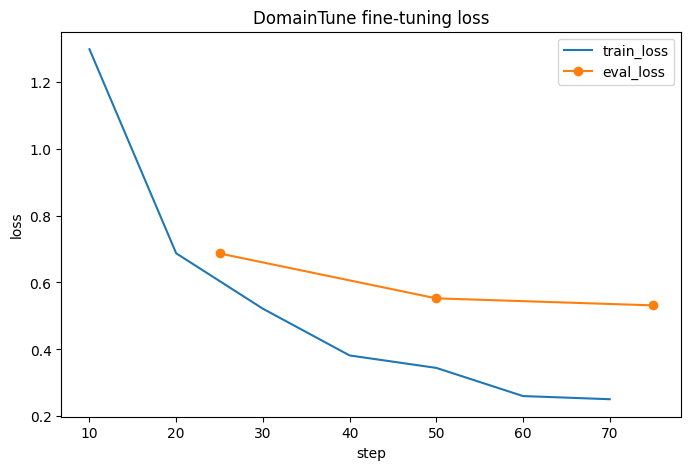

In [18]:
# Plot the train/eval loss curves from the trainer's log history.
import matplotlib.pyplot as plt

history = trainer.state.log_history
train_points = [(h["step"], h["loss"]) for h in history if "loss" in h]
eval_points = [(h["step"], h["eval_loss"]) for h in history if "eval_loss" in h]

plt.figure(figsize=(8, 5))
if train_points:
    steps, losses = zip(*train_points)
    plt.plot(steps, losses, label="train_loss")
if eval_points:
    steps, losses = zip(*eval_points)
    plt.plot(steps, losses, label="eval_loss", marker="o")
plt.xlabel("step")
plt.ylabel("loss")
plt.legend()
plt.title("DomainTune fine-tuning loss")
plt.show()


## 10. Save the DomainTune LoRA adapter

We save the adapter only — small (a few MB to tens of MB), not a full copy
of Qwen's weights. At inference time, load the base model + this adapter
together (see Section 12 for exactly that pattern).


In [19]:
ADAPTER_DIR = "domaintune-adapter"
trainer.model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print(f"Adapter and tokenizer saved to ./{ADAPTER_DIR}/")
print(os.listdir(ADAPTER_DIR))


Adapter and tokenizer saved to ./domaintune-adapter/
['tokenizer.json', 'tokenizer_config.json', 'README.md', 'adapter_config.json', 'chat_template.jinja', 'adapter_model.safetensors']


## 11. Export the adapter as a ZIP (for Kaggle)

In [20]:
zip_path = shutil.make_archive("domaintune_adapter", "zip", ADAPTER_DIR)
print(f"Created ZIP: {zip_path}")
# On Kaggle this lands in /kaggle/working/ and is downloadable from the
# notebook's Output tab. In Colab, grab it from the Files panel instead.


Created ZIP: /kaggle/working/domaintune_adapter.zip


## 12. Quick qualitative check — base vs fine-tuned

**This is an informal preview, not the real evaluation.** We run a handful
of validation examples through (a) the untouched base model with the same
instruction prompt, and (b) the base model + our LoRA adapter, and just
look at the outputs side by side against ground truth. The actual
evaluation (field-level exact match, complete-record accuracy, structured-
output validity, across the full test set) is a separate step — we'll
design and run it together once these qualitative results look reasonable.


In [21]:
def generate_json(model_to_use, row, max_new_tokens=200):
    messages = [{"role": "user", "content": f"{row[INSTRUCTION_KEY]}\n\n{row[INPUT_KEY]}"}]
    prompt_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(prompt_text, return_tensors="pt").to(model_to_use.device)
    with torch.no_grad():
        output_ids = model_to_use.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
        )
    generated = output_ids[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True).strip()


# Fine-tuned model = current `model` (base + trained LoRA adapter), already
# in memory. For the base-model comparison, load a second, separate, clean
# instance so the adapter can't affect it.
base_model_for_comparison = load_base_model()

preview_rows = val_rows[:5]

for row in preview_rows:
    print("=" * 80)
    print("key:", row["key"])
    print("ground truth: ", row[OUTPUT_KEY])
    print("base model:   ", generate_json(base_model_for_comparison, row))
    print("fine-tuned:   ", generate_json(model, row))
    print()


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

key: X51005746204
ground truth:  {"company": "BEMED (SP) SDN BHD.", "date": "2018-03-27", "address": "NO.49, JALAN DLNARG U3/G, SUBANG PERDANA, 40150 SHAH ALAM, SELANGOR D.E.", "total": "308.70"}
base model:    ```json
{
    "company": "BEMED (SP) SDN. BHD.",
    "date": "2018-03-27",
    "address": {
        "street": "No.49",
        "city": "SHAH ALAM",
        "state": "SPINA",
        "zip_code": "03-7845"
    },
    "total": {
        "amount": "$308,70",
        "currency": "MYR"
    }
}
```
fine-tuned:    {"company": "BEMED (SP) SDN. BHD.", "date": "2018-03-27", "address": "NO.49, JALAN DINAR G U3/G, SUBANG PERDANA, 40150 SHAH ALAM, SELANGOR D.E.", "total": "308.70"}

key: X00016469619
ground truth:  {"company": "INDAH GIFT & HOME DECO", "date": "2018-10-19", "address": "27, JALAN DEDAP 13, TAMAN JOHOR JAYA, 81100 JOHOR BAHRU, JOHOR.", "total": "60.30"}
base model:    ```json
{
    "company": "INDAH GIFT & HOME DECO",
    "date": "19/10/2018",
    "address": {
        "street":

## 13. Few-shot baseline + full evaluation (test set)

Section 12 was a 5-example eyeball check. Before calling this project's
central question answered, we need real numbers across the full 100-example
test set — and a fair comparison. Zero-shot prompting isn't the only cheap
alternative to fine-tuning; **few-shot prompting** (showing the base model
2-3 worked examples in the prompt) is the obvious next thing a practitioner
would try before reaching for fine-tuning, so we evaluate three variants:

1. **Zero-shot base** — base model, instruction only (what Section 12 used).
2. **Few-shot base** — base model, instruction + 3 worked examples.
3. **Fine-tuned** — base model + our LoRA adapter.

**Metrics** (the ones worth having ready for an interview):
- **JSON validity rate** — did the raw generation parse as valid JSON at all
  (after stripping markdown code fences, since the base model wraps output
  in ```json blocks)?
- **Per-field exact match** — `company`, `date`, `total` compared exactly
  after light normalization (whitespace only — the training targets are
  already canonicalized, so this is a fair bar).
- **Address match, exact and fuzzy** — address is long free text where a
  transcription variant (e.g. a differently-spelled street name) shouldn't
  count as a total failure. We report strict exact match *and* a fuzzy
  match (`difflib` similarity ratio ≥ 0.85) separately, rather than picking
  one and hiding the other.
- **Complete-record accuracy, strict and practical** — strict = all 4 fields
  exact match; practical = company/date/total exact **and** address fuzzy
  match ≥ 0.85 (a more realistic bar for a real extraction pipeline where
  minor address transcription differences are tolerable).
- **Average generation latency** — LoRA's inference overhead should be
  negligible; worth confirming rather than assuming.


### 13.1 Build the few-shot prompt

In [22]:
import difflib

# Few-shot exemplars: the 3 shortest OCR receipts in the TRAINING set (never
# test/val, to avoid leakage). Shortest examples keep the few-shot prompt a
# reasonable length while still demonstrating the exact flat JSON schema we
# want, including how a typical noisy OCR block looks.
FEW_SHOT_EXEMPLARS = sorted(train_rows, key=lambda r: len(r[INPUT_KEY]))[:3]

print(f"Few-shot exemplar OCR lengths (chars): "
      f"{[len(r[INPUT_KEY]) for r in FEW_SHOT_EXEMPLARS]}")
for r in FEW_SHOT_EXEMPLARS:
    print(" -", r["key"])


def build_messages_for_generation(row, few_shot=False):
    """Build the chat messages list for generation (no assistant turn for
    the target row - that's what we're generating)."""
    messages = []
    if few_shot:
        for ex in FEW_SHOT_EXEMPLARS:
            messages.append({"role": "user", "content": f"{ex[INSTRUCTION_KEY]}\n\n{ex[INPUT_KEY]}"})
            messages.append({"role": "assistant", "content": ex[OUTPUT_KEY]})
    messages.append({"role": "user", "content": f"{row[INSTRUCTION_KEY]}\n\n{row[INPUT_KEY]}"})
    return messages


Few-shot exemplar OCR lengths (chars): [169, 247, 284]
 - X51005442341
 - X51008164510
 - X51006466778


### 13.2 Robust JSON extraction from raw generations

In [23]:
import re as _re  # local alias to avoid clobbering the `re` imported earlier

EXPECTED_KEYS = ["company", "date", "address", "total"]

def _first_parseable_dict(raw_text):
    """Cascading parse: direct -> strip code fences -> regex-extract first
    {...} block. Returns the parsed dict AS-IS (keys/types not filtered or
    coerced) or None if nothing parses."""
    candidates = [raw_text.strip()]

    fence_match = _re.search(r"```(?:json)?\s*(.*?)\s*```", raw_text, _re.DOTALL)
    if fence_match:
        candidates.append(fence_match.group(1).strip())

    brace_match = _re.search(r"\{.*\}", raw_text, _re.DOTALL)
    if brace_match:
        candidates.append(brace_match.group(0).strip())

    for candidate in candidates:
        try:
            parsed = json.loads(candidate)
            if isinstance(parsed, dict):
                return parsed
        except (json.JSONDecodeError, TypeError):
            continue
    return None


def extract_json_fields(raw_text):
    """Best-effort extraction of a {company, date, address, total} dict from
    a raw model generation, filtered/coerced to exactly our 4 expected keys.
    Returns a dict (missing keys filled with None) or None if nothing
    parseable was found at all. NOTE: this is deliberately lenient about
    schema shape (e.g. a nested address dict still "succeeds" here) - use
    check_schema_validity() separately to catch schema-shape violations."""
    parsed = _first_parseable_dict(raw_text)
    if parsed is None:
        return None
    return {k: parsed.get(k) for k in EXPECTED_KEYS}


def check_schema_validity(raw_text):
    """Stricter than extract_json_fields: does the parsed JSON have EXACTLY
    the 4 expected keys (no extra, no missing, no nesting), with every
    value being a string or null - not a nested object/list/number? This
    is where we catch the base model's dominant failure mode (emitting
    address/total as nested objects), which extract_json_fields' lenient
    .get()-based extraction doesn't surface at all."""
    parsed = _first_parseable_dict(raw_text)
    if parsed is None:
        return False
    if set(parsed.keys()) != set(EXPECTED_KEYS):
        return False
    for value in parsed.values():
        if value is not None and not isinstance(value, str):
            return False
    return True


### 13.3 Field comparison logic

In [24]:
from collections import Counter

def light_normalize(value):
    """Whitespace-only normalization for comparison - the training targets
    are already canonicalized (Notebook 1), so this just guards against
    trivial formatting noise in generated text, not a re-normalization."""
    if value is None:
        return None
    if not isinstance(value, str):
        value = str(value)
    value = value.strip()
    value = _re.sub(r"\s+", " ", value)
    return value if value else None


def fields_match(gt_value, pred_value, fuzzy=False, threshold=0.85):
    gt_norm = light_normalize(gt_value)
    pred_norm = light_normalize(pred_value)
    if gt_norm is None and pred_norm is None:
        return True  # both correctly absent
    if gt_norm is None or pred_norm is None:
        return False  # one present, one absent - not a match
    if not fuzzy:
        return gt_norm == pred_norm
    ratio = difflib.SequenceMatcher(None, gt_norm.lower(), pred_norm.lower()).ratio()
    return ratio >= threshold


def _tokenize_for_f1(text):
    if not text:
        return []
    text = text.lower()
    text = _re.sub(r"[^a-z0-9\s]", " ", text)  # drop punctuation, keep alnum
    return [t for t in text.split() if t]


def token_precision_recall_f1(gt_value, pred_value):
    """Bag-of-words token precision/recall/F1 between two free-text strings
    (used for address, where a single similarity ratio hides WHICH kind of
    error occurred - dropped content vs hallucinated extra content).
    Returns (precision, recall, f1), each in [0, 1]. Both-empty counts as a
    perfect match; one-empty-one-not counts as a total miss."""
    gt_tokens = _tokenize_for_f1(light_normalize(gt_value))
    pred_tokens = _tokenize_for_f1(light_normalize(pred_value))

    if not gt_tokens and not pred_tokens:
        return 1.0, 1.0, 1.0
    if not gt_tokens or not pred_tokens:
        return 0.0, 0.0, 0.0

    gt_counts = Counter(gt_tokens)
    pred_counts = Counter(pred_tokens)
    overlap = sum((gt_counts & pred_counts).values())

    precision = overlap / len(pred_tokens)
    recall = overlap / len(gt_tokens)
    f1 = 0.0 if (precision + recall) == 0 else 2 * precision * recall / (precision + recall)
    return precision, recall, f1


### 13.4 Run inference across the full test set for all 3 variants

In [25]:
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, **kwargs):
        return iterable


def generate_raw(model_to_use, row, few_shot=False, max_new_tokens=200):
    messages = build_messages_for_generation(row, few_shot=few_shot)
    prompt_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(prompt_text, return_tensors="pt").to(model_to_use.device)

    start = time.perf_counter()
    with torch.no_grad():
        output_ids = model_to_use.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
        )
    elapsed = time.perf_counter() - start

    generated = output_ids[0][inputs["input_ids"].shape[1]:]
    text = tokenizer.decode(generated, skip_special_tokens=True).strip()
    return text, elapsed


import time

VARIANTS = {
    "zero_shot_base": {"model": base_model_for_comparison, "few_shot": False},
    "few_shot_base":  {"model": base_model_for_comparison, "few_shot": True},
    "fine_tuned":     {"model": model, "few_shot": False},
}

raw_results = {name: [] for name in VARIANTS}

for name, cfg in VARIANTS.items():
    print(f"Running variant: {name} ({len(test_rows)} examples)...")
    for row in tqdm(test_rows, desc=name):
        text, elapsed = generate_raw(cfg["model"], row, few_shot=cfg["few_shot"])
        raw_results[name].append({"key": row["key"], "raw_text": text, "elapsed": elapsed,
                                   "ground_truth": json.loads(row[OUTPUT_KEY])})

print("Done. Example raw result:")
print(raw_results["fine_tuned"][0])


Running variant: zero_shot_base (100 examples)...


zero_shot_base:   0%|          | 0/100 [00:00<?, ?it/s]

Running variant: few_shot_base (100 examples)...


few_shot_base:   0%|          | 0/100 [00:00<?, ?it/s]

Running variant: fine_tuned (100 examples)...


fine_tuned:   0%|          | 0/100 [00:00<?, ?it/s]

Done. Example raw result:
{'key': 'X51005675099', 'raw_text': '{"company": "SUPER TERMINAL SDN BHD", "date": "2018-01-20", "address": "NO. 18 & 19, JALAN AIR PANAS 52100 KUALA LUMPUR.", "total": "132.50"}', 'elapsed': 6.314640569999938, 'ground_truth': {'company': 'SUPER TERMINAL SDN BHD', 'date': '2018-01-20', 'address': 'NO. 18 & 19, TAMAN CITY, JALAN KUCHING, 52100 KUALA LUMPUR', 'total': '132.50'}}


### 13.5 Parse predictions and score every example

In [26]:
scored_results = {name: [] for name in VARIANTS}

for name, results in raw_results.items():
    for r in results:
        parsed = extract_json_fields(r["raw_text"])
        json_valid = parsed is not None
        schema_valid = check_schema_validity(r["raw_text"])
        gt = r["ground_truth"]
        pred = parsed or {k: None for k in EXPECTED_KEYS}

        company_exact = fields_match(gt.get("company"), pred.get("company"))
        date_exact = fields_match(gt.get("date"), pred.get("date"))
        total_exact = fields_match(gt.get("total"), pred.get("total"))
        address_exact = fields_match(gt.get("address"), pred.get("address"), fuzzy=False)
        address_fuzzy = fields_match(gt.get("address"), pred.get("address"), fuzzy=True, threshold=0.85)

        # Address token-level F1: separates "dropped part of the address"
        # (low recall) from "hallucinated extra content" (low precision) -
        # more diagnostic than the single fuzzy ratio above.
        addr_precision, addr_recall, addr_f1 = token_precision_recall_f1(
            gt.get("address"), pred.get("address") if isinstance(pred.get("address"), str) else None
        )

        # Missing/empty field rate: did the model output null/empty for a
        # field, regardless of whether that happens to match ground truth.
        fields_missing_in_pred = sum(
            1 for k in EXPECTED_KEYS if light_normalize(pred.get(k)) is None
        )

        completion_token_count = len(
            tokenizer(r["raw_text"], add_special_tokens=False)["input_ids"]
        )

        complete_strict = json_valid and company_exact and date_exact and total_exact and address_exact
        complete_practical = json_valid and company_exact and date_exact and total_exact and address_fuzzy

        scored_results[name].append({
            "key": r["key"],
            "json_valid": json_valid,
            "schema_valid": schema_valid,
            "company_exact": company_exact,
            "date_exact": date_exact,
            "total_exact": total_exact,
            "address_exact": address_exact,
            "address_fuzzy": address_fuzzy,
            "address_precision": addr_precision,
            "address_recall": addr_recall,
            "address_f1": addr_f1,
            "fields_missing_in_pred": fields_missing_in_pred,
            "completion_token_count": completion_token_count,
            "complete_strict": complete_strict,
            "complete_practical": complete_practical,
            "elapsed": r["elapsed"],
        })

print("Scored all examples for all variants (including schema-validity, "
      "address token-F1, and completion length).")


Scored all examples for all variants (including schema-validity, address token-F1, and completion length).


### 13.6 Aggregate metrics table

In [27]:
def aggregate(name):
    rows = scored_results[name]
    n = len(rows)
    def pct(key):
        return 100 * sum(r[key] for r in rows) / n
    def avg(key):
        return sum(r[key] for r in rows) / n
    return {
        "variant": name,
        "json_valid_%": round(pct("json_valid"), 1),
        "schema_valid_%": round(pct("schema_valid"), 1),
        "company_exact_%": round(pct("company_exact"), 1),
        "date_exact_%": round(pct("date_exact"), 1),
        "total_exact_%": round(pct("total_exact"), 1),
        "address_exact_%": round(pct("address_exact"), 1),
        "address_fuzzy_%": round(pct("address_fuzzy"), 1),
        "address_f1": round(avg("address_f1"), 3),
        "address_precision": round(avg("address_precision"), 3),
        "address_recall": round(avg("address_recall"), 3),
        "avg_fields_missing": round(avg("fields_missing_in_pred"), 2),
        "complete_record_strict_%": round(pct("complete_strict"), 1),
        "complete_record_practical_%": round(pct("complete_practical"), 1),
        "avg_completion_tokens": round(avg("completion_token_count"), 1),
        "avg_latency_sec": round(avg("elapsed"), 2),
    }

metrics_df = pd.DataFrame([aggregate(name) for name in VARIANTS])
metrics_df = metrics_df.set_index("variant")
metrics_df


,json_valid_%,schema_valid_%,company_exact_%,date_exact_%,total_exact_%,address_exact_%,address_fuzzy_%,address_f1,address_precision,address_recall,avg_fields_missing,complete_record_strict_%,complete_record_practical_%,avg_completion_tokens,avg_latency_sec
variant,,,,,,,,,,,,,,,
zero_shot_base,83.0,0.0,27.0,35.0,0.0,0.0,0.0,0.000,0.000,0.000,0.68,0.0,0.0,136.2,6.53
few_shot_base,96.0,96.0,55.0,68.0,63.0,0.0,0.0,0.350,0.477,0.290,0.16,0.0,0.0,75.0,4.02
fine_tuned,100.0,100.0,90.0,97.0,96.0,46.0,65.0,0.845,0.868,0.834,0.00,44.0,60.0,82.7,7.19


In [28]:
metrics_df.to_csv("evaluation_metrics.csv")
print("Saved evaluation_metrics.csv")
print()
print(metrics_df.to_string())


Saved evaluation_metrics.csv

                json_valid_%  schema_valid_%  company_exact_%  date_exact_%  total_exact_%  address_exact_%  address_fuzzy_%  address_f1  address_precision  address_recall  avg_fields_missing  complete_record_strict_%  complete_record_practical_%  avg_completion_tokens  avg_latency_sec
variant                                                                                                                                                                                                                                                                                       
zero_shot_base          83.0             0.0             27.0          35.0            0.0              0.0              0.0       0.000              0.000           0.000                0.68                       0.0                          0.0                  136.2             6.53
few_shot_base           96.0            96.0             55.0          68.0           63.0              0.0  

### 13.7 How to read this

- **`schema_valid_%`** vs **`json_valid_%`**: `json_valid_%` only checks
  "did this parse as JSON at all" - a nested `address: {...}` object still
  counts as valid JSON. `schema_valid_%` is the stricter check (exactly the
  4 expected flat keys, string-or-null values) and is where the base
  model's dominant failure mode - emitting nested objects for
  address/total - actually shows up in the numbers.
- **`complete_record_strict_%`** is the headline "did we get the whole
  receipt right, byte-for-byte" number - the hardest, most defensible metric
  to lead with.
- **`complete_record_practical_%`** answers "would this be usable in a real
  pipeline" - it tolerates minor address transcription noise while still
  requiring company/date/total to be exactly right.
- **`address_precision` / `address_recall` / `address_f1`** decompose the
  single fuzzy-match number: low recall means the model is dropping parts
  of the address; low precision means it's adding content that isn't
  there (hallucination). Same F1 can hide very different failure shapes.
- **`avg_fields_missing`** - how often the model outputs null/empty
  regardless of correctness. A high number for the fine-tuned model would
  suggest it's learned to "give up" rather than guess; a high number for a
  base variant is a different failure mode (refusal/uncertainty) than
  hallucination.
- **`avg_completion_tokens`** exists specifically to explain the latency
  anomaly from the first evaluation run (fine-tuned slower than few-shot
  despite being a smaller effective workload per LoRA's design) - compare
  this against `avg_latency_sec` per variant before drawing any conclusion
  about LoRA inference overhead.
- **The zero-shot vs few-shot base gap** tells you how much of the base
  model's failure was a *prompting* problem (fixable for free) vs a
  *capability* problem (needs fine-tuning). If few-shot closes most of the
  gap to fine-tuned, that's an important, honest finding - it means
  fine-tuning's main value here was efficiency/latency/determinism rather
  than raw accuracy, which is still a valid and fundable conclusion.


## 14. Iteration 2: address/OCR augmentation + light regularization

Motivated directly by what Section 13 showed:

- **Overfitting signal**: val loss nearly plateaued epoch 2→3 while train
  loss kept dropping steeply — the model was starting to memorize rather
  than generalize.
- **Address is the one weak field** (46% exact / 65% fuzzy vs. 90-97% for
  the other three), and a concrete failure case showed confident
  hallucination of plausible-but-wrong street content, not just formatting
  noise.

Two changes this round, kept minimal and targeted rather than a broad
hyperparameter sweep:

1. **Address/OCR-noise data augmentation** — for a subset of training
   examples, create an augmented copy with (a) common Malaysian address
   abbreviation swaps (`JALAN`↔`JLN`, `TAMAN`↔`TMN`, etc.) and (b) light
   synthetic OCR character noise (visually-confusable character swaps: O↔0,
   I↔1, S↔5, B↔8), applied to the **input OCR text only** — the ground-truth
   target stays exactly the same canonical string. This directly teaches
   "extract the correct value regardless of superficial input spelling
   noise," which is exactly the address robustness gap we saw.
2. **Light regularization** — `weight_decay=0.01` (was unset/0), LoRA
   dropout `0.1` (was 0.05), plus `num_train_epochs=5` with
   `EarlyStoppingCallback(patience=1)` so the trainer - not a fixed guess -
   decides when val loss stops improving, rather than us hand-picking 3
   epochs upfront.

We reuse `tokenizer`, `encode_example`, `CompletionOnlyCollator`,
`make_training_args`, `apply_lora`, and the evaluation helpers from
Section 13 - no need to redefine any of that.


### 14.1 Build the augmented training set

In [29]:
import random as _random
_random.seed(123)

# Common Malaysian address abbreviation pairs - swapped in either direction
# so the model sees both forms for the same underlying address content,
# while the ground-truth target is left untouched.
ADDRESS_ABBREVIATIONS = [
    ("JALAN", "JLN"), ("TAMAN", "TMN"), ("KAMPUNG", "KG"),
    ("LORONG", "LRG"), ("BANDAR", "BDR"), ("PERSIARAN", "PSN"),
    ("SIMPANG", "SPG"), ("BUKIT", "BKT"),
]

# Visually-confusable character pairs, mimicking common OCR misreads.
OCR_CONFUSABLE_CHARS = {
    "O": "0", "0": "O", "I": "1", "1": "I", "S": "5", "5": "S",
    "B": "8", "8": "B", "Z": "2",
}

def add_ocr_noise(text, char_noise_prob=0.02):
    chars = list(text)
    for i, ch in enumerate(chars):
        if ch.upper() in OCR_CONFUSABLE_CHARS and _random.random() < char_noise_prob:
            replacement = OCR_CONFUSABLE_CHARS[ch.upper()]
            chars[i] = replacement.lower() if ch.islower() else replacement
    return "".join(chars)


def swap_address_abbreviations(text):
    for full, abbr in ADDRESS_ABBREVIATIONS:
        if _random.random() < 0.5:
            if _random.random() < 0.5:
                text = re.sub(rf"\b{full}\b", abbr, text)
            else:
                text = re.sub(rf"\b{abbr}\b", full, text)
    return text


def augment_row(row):
    augmented_input = swap_address_abbreviations(row[INPUT_KEY])
    augmented_input = add_ocr_noise(augmented_input)
    return {
        "key": row["key"] + "_aug",
        INSTRUCTION_KEY: row[INSTRUCTION_KEY],
        INPUT_KEY: augmented_input,
        OUTPUT_KEY: row[OUTPUT_KEY],  # target stays canonical/unchanged
    }


AUGMENT_FRACTION = 0.4
n_to_augment = int(len(train_rows) * AUGMENT_FRACTION)
rows_to_augment = _random.sample(train_rows, n_to_augment)
augmented_rows = [augment_row(r) for r in rows_to_augment]

train_rows_v2 = train_rows + augmented_rows
print(f"Original train size: {len(train_rows)}")
print(f"Augmented copies added: {len(augmented_rows)}")
print(f"New train size: {len(train_rows_v2)}")

# Spot check: confirm the target is unchanged and the input is perturbed.
orig = rows_to_augment[0]
aug = next(r for r in augmented_rows if r["key"] == orig["key"] + "_aug")
print("\nOriginal input snippet:", orig[INPUT_KEY][:200])
print("Augmented input snippet:", aug[INPUT_KEY][:200])
print("Target unchanged:", orig[OUTPUT_KEY] == aug[OUTPUT_KEY])


Original train size: 789
Augmented copies added: 315
New train size: 1104

Original input snippet: RESTORAN WAN SHENG
002043319-W
NO.2
SEKSYEN 9
43200 CHERAS
GST REG NO: 001335787520
TAX INVOICE
INV NO.: 1201504
CASHIER: THANDAR
DATE
: 20-06-2018 13:11:45
DESCRIPTION
QTY
U.PRICE
TOTAL
TAX
TEH (B)
1
Augmented input snippet: RESTORAN WAN SHENG
002043319-W
NO.2
SEKSYEN 9
43200 CHERAS
GST REG NO: 001335787520
TAX INVOICE
INV NO.: 1201504
CASHIER: THANDAR
DATE
: 20-06-2018 13:1I:45
DESCRIPTION
QTY
U.PRICE
TOTAL
TAX
TEH (B)
1
Target unchanged: True


### 14.2 Tokenize the augmented set

Reusing `encode_example` from Section 6 unchanged - the augmentation only
changed the raw text going in, not the tokenization/masking logic.
Validation and test sets are **not** augmented, so evaluation stays honest.


In [30]:
train_ds_v2 = Dataset.from_list([encode_example(r) for r in train_rows_v2])

n_before = len(train_ds_v2)
train_ds_v2 = train_ds_v2.filter(has_supervised_tokens)
print(f"Train v2 examples: {n_before} -> {len(train_ds_v2)} after dropping fully-masked")


Filter:   0%|          | 0/1104 [00:00<?, ? examples/s]

Train v2 examples: 1104 -> 1104 after dropping fully-masked


### 14.3 Fresh model with adjusted LoRA dropout

In [31]:
del model
gc.collect()
torch.cuda.empty_cache()

model_v2 = load_base_model()
model_v2 = apply_lora(model_v2, lora_dropout=0.1)


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

trainable params: 8,798,208 || all params: 502,830,976 || trainable%: 1.7497


### 14.4 Train with weight decay + early stopping

In [32]:
from transformers import EarlyStoppingCallback

training_args_v2 = make_training_args(
    output_dir="domaintune_training_v2",
    num_train_epochs=5,           # ceiling, not a target - early stopping decides
    per_device_train_batch_size=PER_DEVICE_BATCH_SIZE,
    per_device_eval_batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    learning_rate=2e-4,
    warmup_ratio=0.03,
    weight_decay=0.01,            # new: light L2 regularization
    lr_scheduler_type="cosine",
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    bf16=USE_BF16,
    fp16=USE_FP16,
    optim="paged_adamw_8bit",
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    report_to=[],
)

gc.collect()
torch.cuda.empty_cache()

trainer_v2 = Trainer(
    model=model_v2,
    args=training_args_v2,
    train_dataset=train_ds_v2,
    eval_dataset=val_ds,  # unchanged, un-augmented validation set
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
)

train_result_v2 = trainer_v2.train()
print(train_result_v2)


NOTE: this transformers version doesn't support these TrainingArguments and they were dropped: ['warmup_ratio']
  -> warmup_ratio unsupported here; proceeding without warmup (consider adding warmup_steps manually if this matters to you)


Epoch,Training Loss,Validation Loss
1,0.527920,0.570869
2,0.236515,0.463196
3,0.126443,0.461066
4,0.065338,0.482299


TrainOutput(global_step=140, training_loss=0.3198010580880301, metrics={'train_runtime': 4873.2404, 'train_samples_per_second': 1.133, 'train_steps_per_second': 0.036, 'total_flos': 5541165692943360.0, 'train_loss': 0.3198010580880301, 'epoch': 4.0})


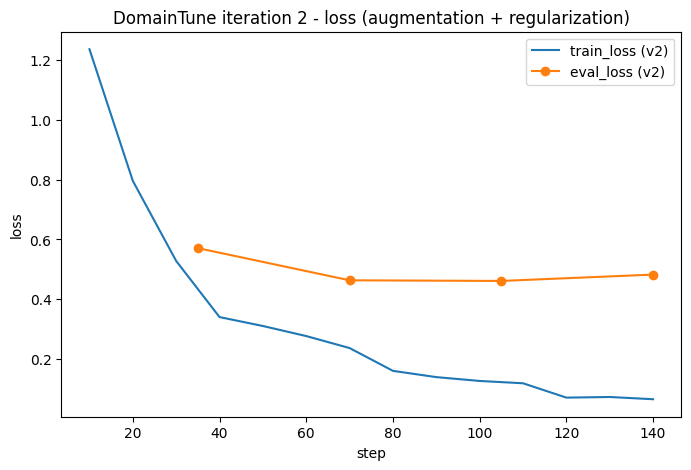

Actual epochs trained (may be fewer than 5 if early stopping triggered):
4.0


In [33]:
history_v2 = trainer_v2.state.log_history
train_points_v2 = [(h["step"], h["loss"]) for h in history_v2 if "loss" in h]
eval_points_v2 = [(h["step"], h["eval_loss"]) for h in history_v2 if "eval_loss" in h]

plt.figure(figsize=(8, 5))
if train_points_v2:
    steps, losses = zip(*train_points_v2)
    plt.plot(steps, losses, label="train_loss (v2)")
if eval_points_v2:
    steps, losses = zip(*eval_points_v2)
    plt.plot(steps, losses, label="eval_loss (v2)", marker="o")
plt.xlabel("step")
plt.ylabel("loss")
plt.legend()
plt.title("DomainTune iteration 2 - loss (augmentation + regularization)")
plt.show()

print("Actual epochs trained (may be fewer than 5 if early stopping triggered):")
print(max(h.get("epoch", 0) for h in history_v2))


### 14.5 Save the iteration-2 adapter

In [34]:
ADAPTER_DIR_V2 = "domaintune-adapter-v2"
trainer_v2.model.save_pretrained(ADAPTER_DIR_V2)
tokenizer.save_pretrained(ADAPTER_DIR_V2)
print(f"Adapter and tokenizer saved to ./{ADAPTER_DIR_V2}/")

zip_path_v2 = shutil.make_archive("domaintune_adapter_v2", "zip", ADAPTER_DIR_V2)
print(f"Created ZIP: {zip_path_v2}")


Adapter and tokenizer saved to ./domaintune-adapter-v2/
Created ZIP: /kaggle/working/domaintune_adapter_v2.zip


### 14.6 Re-evaluate on the same test set - 4-way comparison

Same test set, same scoring functions from Section 13 - only the model
under test (`model_v2`) and the variant name are new. This keeps the
comparison apples-to-apples with the first evaluation round.


In [35]:
VARIANTS["fine_tuned_v2"] = {"model": model_v2, "few_shot": False}

print("Running variant: fine_tuned_v2 (100 examples)...")
raw_results["fine_tuned_v2"] = []
for row in tqdm(test_rows, desc="fine_tuned_v2"):
    text, elapsed = generate_raw(model_v2, row, few_shot=False)
    raw_results["fine_tuned_v2"].append({
        "key": row["key"], "raw_text": text, "elapsed": elapsed,
        "ground_truth": json.loads(row[OUTPUT_KEY]),
    })
print("Done.")


Running variant: fine_tuned_v2 (100 examples)...


fine_tuned_v2:   0%|          | 0/100 [00:00<?, ?it/s]

Done.


In [36]:
# Score the new variant using the exact same logic as Section 13.5.
name = "fine_tuned_v2"
scored_results[name] = []
for r in raw_results[name]:
    parsed = extract_json_fields(r["raw_text"])
    json_valid = parsed is not None
    schema_valid = check_schema_validity(r["raw_text"])
    gt = r["ground_truth"]
    pred = parsed or {k: None for k in EXPECTED_KEYS}

    company_exact = fields_match(gt.get("company"), pred.get("company"))
    date_exact = fields_match(gt.get("date"), pred.get("date"))
    total_exact = fields_match(gt.get("total"), pred.get("total"))
    address_exact = fields_match(gt.get("address"), pred.get("address"), fuzzy=False)
    address_fuzzy = fields_match(gt.get("address"), pred.get("address"), fuzzy=True, threshold=0.85)
    addr_precision, addr_recall, addr_f1 = token_precision_recall_f1(
        gt.get("address"), pred.get("address") if isinstance(pred.get("address"), str) else None
    )
    fields_missing_in_pred = sum(1 for k in EXPECTED_KEYS if light_normalize(pred.get(k)) is None)
    completion_token_count = len(tokenizer(r["raw_text"], add_special_tokens=False)["input_ids"])
    complete_strict = json_valid and company_exact and date_exact and total_exact and address_exact
    complete_practical = json_valid and company_exact and date_exact and total_exact and address_fuzzy

    scored_results[name].append({
        "key": r["key"], "json_valid": json_valid, "schema_valid": schema_valid,
        "company_exact": company_exact, "date_exact": date_exact, "total_exact": total_exact,
        "address_exact": address_exact, "address_fuzzy": address_fuzzy,
        "address_precision": addr_precision, "address_recall": addr_recall, "address_f1": addr_f1,
        "fields_missing_in_pred": fields_missing_in_pred,
        "completion_token_count": completion_token_count,
        "complete_strict": complete_strict, "complete_practical": complete_practical,
        "elapsed": r["elapsed"],
    })

print(f"Scored {name}.")


Scored fine_tuned_v2.


In [37]:
metrics_df_v2 = pd.DataFrame([aggregate(name) for name in VARIANTS])
metrics_df_v2 = metrics_df_v2.set_index("variant")
metrics_df_v2.to_csv("evaluation_metrics_v2.csv")
print("Saved evaluation_metrics_v2.csv")
print()
metrics_df_v2


Saved evaluation_metrics_v2.csv



,json_valid_%,schema_valid_%,company_exact_%,date_exact_%,total_exact_%,address_exact_%,address_fuzzy_%,address_f1,address_precision,address_recall,avg_fields_missing,complete_record_strict_%,complete_record_practical_%,avg_completion_tokens,avg_latency_sec
variant,,,,,,,,,,,,,,,
zero_shot_base,83.0,0.0,27.0,35.0,0.0,0.0,0.0,0.000,0.000,0.000,0.68,0.0,0.0,136.2,6.53
few_shot_base,96.0,96.0,55.0,68.0,63.0,0.0,0.0,0.350,0.477,0.290,0.16,0.0,0.0,75.0,4.02
fine_tuned,100.0,100.0,90.0,97.0,96.0,46.0,65.0,0.845,0.868,0.834,0.00,44.0,60.0,82.7,7.19
fine_tuned_v2,100.0,100.0,92.0,97.0,97.0,55.0,74.0,0.872,0.883,0.870,0.00,54.0,68.0,84.1,7.33


### 14.7 What to look for

- **`fine_tuned` vs `fine_tuned_v2` on `address_exact_%` / `address_f1`**
  is the number that tells us whether augmentation actually helped the
  field it targeted - if it didn't move, the address gap is more likely a
  data-diversity/coverage limitation than something more training on the
  same 987 receipts can fix.
- **Epochs actually trained** (printed above the loss plot) - if early
  stopping triggered before reaching 5, that confirms 3 epochs in iteration
  1 was close to the real ceiling for this dataset size, rather than
  arbitrarily too few.
- **`complete_record_practical_%`** is the cleanest single number for "did
  this iteration actually improve the model," since it's the metric most
  directly tied to real usability.
- If v2 is a clear improvement: use `domaintune-adapter-v2` going forward.
  If v2 is roughly flat or worse: that's still a useful, honest result -
  it means the address gap needs a different kind of intervention (more/
  more-diverse real training data, or a larger base model) rather than
  augmentation or regularization, and `domaintune-adapter` (v1) remains the
  one to carry forward into the FastAPI/Docker step.


## 15. Next steps

- Compare `fine_tuned` vs `fine_tuned_v2` in Section 14.6's table -
  specifically `address_exact_%`, `address_f1`, and
  `complete_record_practical_%`. That comparison decides which adapter
  moves forward.
- Check how many epochs iteration 2 actually trained before early stopping
  triggered (Section 14.4's output) - this tells us whether 3 epochs in
  iteration 1 was near-optimal or genuinely too few for this dataset size.
- Whichever adapter wins, move its inference code (loading base model +
  adapter, `generate_json`/`extract_json_fields`) into `src/`, build the
  FastAPI layer, and Dockerize.
- If v2 doesn't meaningfully improve address performance, that's a valid
  stopping point for this iteration cycle - the honest conclusion becomes
  "address extraction has a data-diversity ceiling on this dataset size,"
  which is itself a defensible finding to present, not a failure.
